In [62]:
from google.colab import files

uploaded = files.upload()
upload2 = files.upload()

Saving cleaned_draft_reports.csv to cleaned_draft_reports.csv


We begin by loading the dataset containing offensive player statistics. This will serve as the backbone of our analysis.

By using pandas, we can efficiently manipulate and filter the data, while numpy provides support for numerical operations later on.

The dataset is loaded into a DataFrame called `df_offense`. Basic error handling is included to ensure the file is properly located before proceeding.

In [63]:
import pandas as pd
import numpy as np

# Load the uploaded CSV file into a DataFrame
try:
    df_offense = pd.read_csv('yearly_player_stats_offense.csv')
    print("yearly_player_stats_offense.csv loaded successfully.")
except FileNotFoundError:
    print("Error: 'yearly_player_stats_offense.csv' not found. Please ensure it has been uploaded.")
    df_offense = pd.DataFrame() # Create an empty DataFrame to avoid errors

# Display basic information about the DataFrame and its columns
if not df_offense.empty:
    print("\nDataFrame Info:")
    df_offense.info()
    print("\nFirst 5 rows of the DataFrame:")
    display(df_offense.head())

yearly_player_stats_offense.csv loaded successfully.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5192 entries, 0 to 5191
Columns: 412 entries, player_id to delta_yptouch
dtypes: float64(400), int64(5), object(7)
memory usage: 16.3+ MB

First 5 rows of the DataFrame:


,player_id,player_name,position,birth_year,draft_year,draft_round,draft_pick,draft_ovr,height,weight,...,delta_comp_pct,delta_int_pct,delta_pass_td_pct,delta_ypa,delta_yptarget,delta_ypr,delta_rush_td_pct,delta_ypc,delta_td_pct,delta_yptouch
0,00-0000865,Charlie Batch,QB,1974,1998.0,2.0,30.0,60.0,74.0,216.0,...,0.220036,-1.0,-1.0,0.025641,0.000000,0.000000,0.0,0.000000,-0.909091,-0.388795
1,00-0004541,Donald Driver,WR,1975,1999.0,7.0,7.0,213.0,72.0,194.0,...,0.000000,NaN,NaN,0.000000,-0.172028,-0.068732,0.0,0.000000,49.000000,1.226852
2,00-0006101,Tony Gonzalez,TE,1976,1997.0,1.0,13.0,13.0,77.0,247.0,...,0.000000,0.0,0.0,0.000000,0.084371,-0.157447,0.0,0.000000,2.166667,0.337838
3,00-0007091,Matt Hasselbeck,QB,1975,1998.0,6.0,34.0,187.0,76.0,235.0,...,0.147482,-1.0,-1.0,-0.145503,0.000000,0.000000,-1.0,-0.351474,0.500000,0.272912
4,00-0010346,Peyton Manning,QB,1976,1998.0,1.0,1.0,1.0,77.0,230.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-1.0,-0.942308,5.000000,1.015544


At this stage, we narrow the dataset to players who actually saw the field — specifically, those with over 500 offensive snaps.

From there, we shift our focus to late-round draft picks (Round 3 and beyond). These are the players most likely to be overlooked during the draft, making them ideal candidates for identifying “hidden gem” traits.

By combining these filters, we isolate a group of players who earned significant roles despite lower draft capital — exactly the type of success stories we want to analyze.

In [64]:
import pandas as pd
import numpy as np

# Ensure required columns exist
required_columns = ['player_name', 'position', 'offense_snaps', 'fantasy_points_ppr', 'draft_round']

for col in required_columns:
    if col not in df_offense.columns:
        raise ValueError(f"Missing required column: '{col}'. Please check the CSV file.")

# Fill NaN draft_round values with 7 (assuming NaN means undrafted or very late round)
df_offense['draft_round'] = df_offense['draft_round'].fillna(7)

# Filter for players with more than 500 snap counts AND drafted 3rd round or later
filtered_players_df = df_offense[
    (df_offense['offense_snaps'] > 500) &
    (df_offense['draft_round'] >= 3)
].copy()

# Calculate the 40th percentile for fantasy points among the filtered players for top 60%
# (Top 60% means fantasy points are greater than or equal to the 40th percentile)
if not filtered_players_df.empty:
    fantasy_threshold = filtered_players_df['fantasy_points_ppr'].quantile(0.40)
    print(f"\nFantasy points threshold for top 60%: {fantasy_threshold:.2f}")

    # Filter for strong fantasy performances (top 60%) for *each season*
    seasons_meeting_criteria_df = filtered_players_df[
        filtered_players_df['fantasy_points_ppr'] >= fantasy_threshold
    ].copy()

    # Count how many seasons each player met the criteria
    player_season_counts = seasons_meeting_criteria_df.groupby('player_name').size().reset_index(name='num_seasons_top_60_percent')

    # Identify players who met the criteria in 3 or more seasons
    consistent_players = player_season_counts[player_season_counts['num_seasons_top_60_percent'] >= 3]['player_name'].tolist()

    # Filter the 'seasons_meeting_criteria_df' to include only the consistent players
    # And display all their seasons that met the criteria
    final_filtered_df = seasons_meeting_criteria_df[
        seasons_meeting_criteria_df['player_name'].isin(consistent_players)
    ].copy()

    print(f"\nNumber of individual player-seasons after filtering for consistency (top 60% in 3+ seasons): {len(final_filtered_df)}")
    print(f"Number of unique consistent players: {len(final_filtered_df['player_name'].unique())}")

    # Display the final filtered players with requested columns
    display_columns = ['player_name', 'position', 'draft_round', 'offense_snaps', 'fantasy_points_ppr']

    # Check if 'college' column exists and add it to display_columns if so
    if 'college' in df_offense.columns:
        display_columns.insert(2, 'college') # Insert 'college' after 'position'

    print("\nPlayers meeting criteria (top 60% in 3 or more seasons):")
    display(final_filtered_df[display_columns].sort_values(by=['player_name', 'position']))

    # Display a table of unique colleges from these players as a list
    if 'college' in final_filtered_df.columns and not final_filtered_df.empty:
        unique_colleges_list = final_filtered_df['college'].dropna().unique().tolist()
        print("\nUnique Colleges of Consistent Players:")
        print(unique_colleges_list)
    elif final_filtered_df.empty:
        print("No consistent players found, so no colleges to display.")
    else:
        print("The 'college' column is not available in the filtered data.")

else:
    print("No players found after filtering by snap counts, draft round, and fantasy performance.")


Fantasy points threshold for top 60%: 148.30

Number of individual player-seasons after filtering for consistency (top 60% in 3+ seasons): 375
Number of unique consistent players: 75

Players meeting criteria (top 60% in 3 or more seasons):


,player_name,position,college,draft_round,offense_snaps,fantasy_points_ppr
2870,Aaron Jones,RB,UTEP,5.0,757.0,357.70
3237,Aaron Jones,RB,UTEP,5.0,608.0,281.60
3630,Aaron Jones,RB,UTEP,5.0,620.0,254.00
4005,Aaron Jones,RB,UTEP,5.0,630.0,243.60
4829,Aaron Jones,RB,UTEP,5.0,753.0,245.60
...,...,...,...,...,...,...
4395,Tyreek Hill,WR,West Alabama,5.0,1470.0,765.20
4819,Tyreek Hill,WR,West Alabama,5.0,906.0,212.20
1238,Tyrod Taylor,QB,Virginia Tech,6.0,923.0,308.60
1578,Tyrod Taylor,QB,Virginia Tech,6.0,969.0,298.92



Unique Colleges of Consistent Players:
['Michigan', 'Utah', 'Tennessee', 'Miami (Fla.)', 'Kansas State', 'Harvard', 'Central Florida', 'Hofstra', 'San Jose State', 'Texas', 'Mississippi', 'LSU', 'Minnesota', 'Miami', 'Central Michigan', 'Oregon St.', 'TCU', 'Florida Atlantic', 'Wisconsin', 'Florida International', 'Mount Union', 'Kent State', 'Southern Methodist', 'Oklahoma', 'California', 'Central Missouri Sta', 'Rutgers', 'Cincinnati', 'UCF', 'Pittsburgh State', 'Virginia Tech', 'Nevada', 'Michigan State', 'Florida State', 'Maryland', 'Duke', 'Northern Iowa', 'Indiana', 'West Alabama', 'Mississippi State', 'Georgia Southern', 'Alabama', 'North Carolina State', 'North Carolina A&T', 'Eastern Washington', 'Toledo', 'Iowa', 'Pittsburgh', 'Penn State', 'UTEP', 'Washington State', 'Auburn', 'Ohio State', 'Iowa State', 'Memphis', 'Tulane', 'Stanford', 'Oklahoma State', 'USC', 'Arizona State']


We follow up by filtering the data even further. We look for players drafted from 2015 and later, which is when scouting report data can be found for players.

In [65]:
import pandas as pd

# Ensure 'draft_year' column exists in final_filtered_df for this additional filter
if 'draft_year' not in final_filtered_df.columns:
    print("Error: 'draft_year' column not found in the filtered data. Cannot apply drafting year filter.")
else:
    # Apply the additional filter for players drafted in 2015 or later
    final_filtered_df_2015_plus = final_filtered_df[final_filtered_df['draft_year'] >= 2015].copy()

    print(f"\nNumber of individual player-seasons after filtering for draft year 2015 or later: {len(final_filtered_df_2015_plus)}")
    print(f"Number of unique consistent players (drafted 2015+): {len(final_filtered_df_2015_plus['player_name'].unique())}")

    # Display the final filtered players with requested columns
    display_columns = ['player_name', 'position', 'draft_year', 'draft_round', 'offense_snaps', 'fantasy_points_ppr']

    # Check if 'college' column exists and add it to display_columns if so
    if 'college' in final_filtered_df_2015_plus.columns:
        display_columns.insert(2, 'college') # Insert 'college' after 'position'

    print("\nPlayers meeting criteria (drafted 2015 or later):")
    display(final_filtered_df_2015_plus[display_columns].sort_values(by=['player_name', 'position']))

    # Display a table of unique colleges from these players as a list
    if 'college' in final_filtered_df_2015_plus.columns and not final_filtered_df_2015_plus.empty:
        unique_colleges_list_2015_plus = final_filtered_df_2015_plus['college'].dropna().unique().tolist()
        print("\nUnique Colleges of Consistent Players (drafted 2015 or later):")
        print(unique_colleges_list_2015_plus)
    elif final_filtered_df_2015_plus.empty:
        print("No consistent players (drafted 2015+) found, so no colleges to display.")
    else:
        print("The 'college' column is not available in the filtered data (drafted 2015+).")



Number of individual player-seasons after filtering for draft year 2015 or later: 166
Number of unique consistent players (drafted 2015+): 35

Players meeting criteria (drafted 2015 or later):


,player_name,position,college,draft_year,draft_round,offense_snaps,fantasy_points_ppr
2870,Aaron Jones,RB,UTEP,2017.0,5.0,757.0,357.7
3237,Aaron Jones,RB,UTEP,2017.0,5.0,608.0,281.6
3630,Aaron Jones,RB,UTEP,2017.0,5.0,620.0,254.0
4005,Aaron Jones,RB,UTEP,2017.0,5.0,630.0,243.6
4829,Aaron Jones,RB,UTEP,2017.0,5.0,753.0,245.6
...,...,...,...,...,...,...,...
3221,Tyreek Hill,WR,West Alabama,2016.0,5.0,2166.0,771.6
3618,Tyreek Hill,WR,West Alabama,2016.0,5.0,1045.0,356.8
3989,Tyreek Hill,WR,West Alabama,2016.0,5.0,859.0,341.6
4395,Tyreek Hill,WR,West Alabama,2016.0,5.0,1470.0,765.2



Unique Colleges of Consistent Players (drafted 2015 or later):
['Maryland', 'Duke', 'Northern Iowa', 'Kansas State', 'Miami', 'Indiana', 'West Alabama', 'Mississippi State', 'Alabama', 'North Carolina State', 'North Carolina A&T', 'Tennessee', 'Eastern Washington', 'Toledo', 'Iowa', 'Pittsburgh', 'Penn State', 'UTEP', 'Florida Atlantic', 'Washington State', 'Auburn', 'Ohio State', 'Iowa State', 'Oklahoma', 'Memphis', 'UCF', 'Tulane', 'Stanford', 'Oklahoma State', 'USC', 'Arizona State']


Last bit of data manipulation, we look for distinct player names.

In [66]:
import pandas as pd

# Ensure 'final_filtered_df_2015_plus' exists and is not empty
if 'final_filtered_df_2015_plus' in locals() and not final_filtered_df_2015_plus.empty:
    # Extract unique players with their name, position, and college
    unique_players_info_2015_plus = final_filtered_df_2015_plus[['player_name', 'position', 'college']].drop_duplicates().sort_values(by='player_name')

    print("\nDistinct Consistent Players (Name, Position, College) drafted 2015 or later:")
    display(unique_players_info_2015_plus)
else:
    print("No consistent players (drafted 2015+) found to extract unique information from.")


Distinct Consistent Players (Name, Position, College) drafted 2015 or later:


,player_name,position,college
2870,Aaron Jones,RB,UTEP
2212,Alvin Kamara,RB,Tennessee
3880,Amon-Ra St. Brown,WR,USC
3447,Antonio Gibson,RB,Memphis
4309,Brock Purdy,QB,Iowa State
2565,Chris Godwin,WR,Penn State
3837,Chuba Hubbard,RB,Oklahoma State
2213,Cooper Kupp,WR,Eastern Washington
1821,Dak Prescott,QB,Mississippi State
3689,Dalton Schultz,TE,Stanford


To analyze scouting reports in a structured way, we define a set of trait categories for both strengths and weaknesses.

Each category is represented by a collection of keywords that commonly appear in draft reports. For example, terms like "vision," "instincts," and "awareness" may all map to a broader cognitive processing trait.

This allows us to convert unstructured text into measurable features, making it possible to compare players and identify patterns across successful late-round picks.

The CSV that is loaded in contains the scouting report full of strenghts and weaknessess for most of the listed players.

In [68]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================
# 1) LOAD / PREP
# =========================

# Load the CSV file directly, letting pandas infer the header and column names.
# The 'cleaned_draft_reports.csv' file has a standard header.
df = pd.read_csv('cleaned_draft_reports.csv')

# Convert 'index' column to numeric, as it's typically an integer.
df['index'] = pd.to_numeric(df['index'])

# Fill NaN values and convert 'strength', 'weakness', and 'position' columns.
df["strength"] = df["strength"].fillna("").astype(str)
df["weakness"] = df["weakness"].fillna("").astype(str)
df["position"] = df["position"].fillna("").astype(str).str.upper()

# =========================
# 2) DETAILED TRAIT MAP
# =========================
# These are intentionally more granular.
# Add/edit phrases as you inspect your reports.

STRENGTH_TRAITS = {
    # universal
    "instincts": [
        "instinctive", "natural feel", "feel for", "reactive", "savvy"
    ],
    "vision": [
        "vision", "reads", "reading", "sees space", "recognize", "lane development",
        "anticipation", "spatial relationships"
    ],
    "processing": [
        "progressions", "decision", "decision-making", "poise", "awareness",
        "works rapidly through", "calm", "process", "timing as a passer"
    ],
    "toughness": [
        "tough", "competitive", "leader", "mentally tough", "resilience", "team leader",
        "strong-willed", "courageous", "willing", "plays through"
    ],
    "versatility": [
        "slot", "outside", "three-down", "return", "multiple", "versatile",
        "lined up", "matchup possibilities", "special teams", "joker role"
    ],
    "physicality": [
        "physical", "strength", "power", "tenacious", "punish", "blocking",
        "contact", "finish", "plays bigger"
    ],

    # receiving / route traits
    "route_detail": [
        "route-runner", "route runner", "routes", "route stems", "stem", "breaks",
        "snap his route", "crisp", "nuanced", "polish", "sells route", "double moves",
        "adjusts routes", "pace through route"
    ],
    "route_physicality": [
        "beat press", "against press", "hand fighter", "hand slap", "stiff jab",
        "leverage", "stacks", "creates space", "physical at the top", "fights for leverage"
    ],
    "separation_quickness": [
        "separation", "exploding out of breaks", "suddenness", "quick lateral step",
        "burst out of cuts", "open throws", "uncover", "sudden stem"
    ],
    "hands": [
        "hands", "pass catcher", "plucker", "sure-handed", "extended hands", "snatch",
        "natural hands", "catches with"
    ],
    "ball_tracking": [
        "tracks", "tracking", "deep-ball tracker", "locating", "find football",
        "body control", "adjust to throws", "high-point", "catch radius"
    ],
    "yac_elusiveness": [
        "after catch", "yac", "elusive", "make-you-miss", "slippery", "wiggle",
        "sudden once", "stop and start", "jump-cut", "misses", "open field"
    ],

    # athletic traits
    "burst": [
        "burst", "instant acceleration", "explosive", "quick gather", "first-step",
        "flip of a switch"
    ],
    "long_speed": [
        "speed", "top speed", "breakaway", "run away", "deep speed", "sprinter",
        "second gear", "home run", "vertical speed"
    ],
    "agility_flexibility": [
        "agile", "agility", "flexible", "fluid", "twist", "spin", "change of direction",
        "hips and feet", "lateral agility"
    ],
    "contact_balance": [
        "balance", "contact balance", "through contact", "ricochet", "post-contact",
        "shrugs off", "balance through contact"
    ],
    "power_finish": [
        "power", "powerful", "drops pads", "punish", "downhill", "leg drive",
        "finish runs", "batter", "stiff-arm", "brute force"
    ],

    # RB specific
    "patience": [
        "patient", "tempo", "varying pace", "wait for", "set up blocks"
    ],
    "one_cut": [
        "one-cut", "cutback", "presses the line", "back-side cuts", "zone-scheme"
    ],
    "pass_pro": [
        "pass protection", "blitz recognition", "pass pro", "squares up blitzers", "blocker"
    ],

    # QB specific
    "accuracy": [
        "accurate", "ball placement", "touch", "strikes", "placement"
    ],
    "arm_talent": [
        "arm strength", "nfl arm", "fit throws", "tight spiral", "drive ball"
    ],
    "pocket_presence": [
        "pocket", "stands tall", "doesn't slide around unnecessarily", "from pocket"
    ],

    # TE / blocker
    "blocking": [
        "run blocking", "in-line blocker", "sustain", "hand placement", "generate movement",
        "approaches blocking like an offensive lineman"
    ],
    "production": [
        "productive", "output", "volume", "stats", "performance", "numbers", "workload", "down"
    ]
}

WEAKNESS_TRAITS = {
    "instincts_issues": [
        "not instinctive", "inconsistent decisions", "feel is concerned", "lacks feel",
        "slow to process", "responds to what is in front", "vision stalls"
    ],
    "vision_issues": [
        "vision can be hit or miss", "vision fails", "won't always see", "misses lane",
        "needs to see", "run lane development", "reads can be late"
    ],
    "processing_issues": [
        "ball needs to come out sooner", "must speed up reads", "locked in", "field blinders",
        "consistency have been issues", "confidence and consistency", "pre-snap plan"
    ],
    "injury": [
        "injury", "durability", "medical", "broken", "knee injuries", "missed", "beat up"
    ],
    "size_frame": [
        "size", "thin frame", "slightly built", "smaller than ideal", "lighter than expected",
        "frame", "short arms"
    ],
    "play_strength": [
        "play strength", "gets muscled", "physical cornerbacks", "below average strength"
    ],

    # receiving / route issues
    "route_detail_issues": [
        "raw getting in and out", "rounded", "telegraphed", "drifts into route turns",
        "monotonous", "predictable", "not enough attention to detail", "upright through routes",
        "footwork in routes", "needs more efficient routes"
    ],
    "route_physicality_issues": [
        "press rides on him", "physical route-matchers", "countering coverage",
        "struggles with physical cornerbacks", "press coverage could be an issue"
    ],
    "separation_issues": [
        "below-average separation", "lacks suddenness", "struggle to separate",
        "doesn't create separation", "windows close quickly", "could struggle to find operating room"
    ],
    "hands_issues": [
        "drops", "focus drops", "body catcher", "issues securing catchable throws",
        "inconsistent hands", "doesn't play with sudden hands"
    ],
    "ball_skills_issues": [
        "ball-tracking is a mixed bag", "tracking deep throws", "contested catches could be a problem",
        "outside his frame", "protect catch space"
    ],

    # athletic limitations
    "burst_issues": [
        "below-average burst", "marginal downhill burst", "average burst", "lacks early acceleration",
        "gear-down", "burst to open space"
    ],
    "long_speed_issues": [
        "lacks speed", "top-end speed in question", "average foot quickness and long speed",
        "play speed needs a boost", "doesn't have the acceleration", "caught from behind"
    ],
    "agility_issues": [
        "tight hips", "stiff hips", "rigid", "lacks fluidity", "too frenetic", "tight-hipped"
    ],

    # RB
    "patience_issues": [
        "impatient", "too quick to quit", "gets too cute", "too eager to bounce",
        "lacks patience", "dancey"
    ],
    "discipline_issues": [
        "off script", "bounce it", "run track", "discipline", "premature in breaking off",
        "run a more disciplined track"
    ],
    "ball_security": [
        "fumbles", "ball security", "tuck ball", "carrying ball away"
    ],
    "pass_pro_issues": [
        "pass protection", "blitz recognition", "protection duties", "cut blocks rather than squaring up"
    ],

    # QB
    "accuracy_issues": [
        "deep ball accuracy", "accuracy dropped", "throws to target", "overthrows",
        "timing to beat", "shies away from tight-window throws"
    ],
    "arm_limitations": [
        "lack of arm strength", "arm limitations", "additional air", "labored delivery"
    ],
    "pocket_issues": [
        "pocket poise", "hyper-aware of pressure", "drop eyes", "back foot", "lacks quickness",
        "bail when defender", "oblivious to pre-snap tells"
    ],

    # blocking
    "blocking_issues": [
        "poor effort as a blocker", "lacks aggression", "run blocking", "won't always fall forward",
        "angles to his work as a blocker are poor"
    ],
    "production_issues": [
        "low production", "inconsistent production", "lack of production", "low volume", "struggles to produce", "inconsistent stats"
    ]
}

Code to help process the scouting report. All non alphabetical chars are removed, and trait counting begins.

In [72]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def count_trait_matches(text, trait_map):
    text = normalize_text(text)
    out = {}

    for trait, phrases in trait_map.items():
        count = 0
        for phrase in phrases:
            phrase = normalize_text(phrase)
            if phrase in text:
                count += 1
        out[trait] = count

    return pd.Series(out)

strength_counts = df["strength"].apply(lambda x: count_trait_matches(x, STRENGTH_TRAITS))
weakness_counts = df["weakness"].apply(lambda x: count_trait_matches(x, WEAKNESS_TRAITS))

strength_counts = strength_counts.add_prefix("str_")
weakness_counts = weakness_counts.add_prefix("weak_")

df_traits = pd.concat([df, strength_counts, weakness_counts], axis=1)

# Presence flags
for col in strength_counts.columns.tolist() + weakness_counts.columns.tolist():
    df_traits[f"{col}_flag"] = (df_traits[col] > 0).astype(int)

df_traits.head()

,index,player_name,position,college,strength,weakness,str_instincts,str_vision,str_processing,str_toughness,...,weak_agility_issues_flag,weak_patience_issues_flag,weak_discipline_issues_flag,weak_ball_security_flag,weak_pass_pro_issues_flag,weak_accuracy_issues_flag,weak_arm_limitations_flag,weak_pocket_issues_flag,weak_blocking_issues_flag,weak_production_issues_flag
0,2870,Aaron Jones,RB,UTEP,,,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2212,Alvin Kamara,RB,Tennessee,Spirited runner with NFL size and speed. Will ...,Vision can be hit or miss. Not an instinctive ...,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0
2,3880,Amon-Ra St. Brown,WR,USC,Crafted a variety of release techniques.\nSmoo...,Play strength might need upgrade against physi...,2,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,3447,Antonio Gibson,RB,Memphis,"Makes explosive plays in running, receiving an...",Only one season of production. Has 34 career r...,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,4309,Brock Purdy,QB,Iowa State,Four-year starter and team leader.\nDifferent ...,Pocket setup lacks quickness.\nField blinders ...,0,1,1,4,...,0,0,0,0,0,1,0,1,0,0


We finishing processing the scouting reports, now it's time to explore what they tell us.

In [70]:
strength_flag_cols = [c for c in df_traits.columns if c.startswith("str_") and c.endswith("_flag")]
weakness_flag_cols = [c for c in df_traits.columns if c.startswith("weak_") and c.endswith("_flag")]

position_strength_summary = (
    df_traits.groupby("position")[strength_flag_cols]
    .mean()
    .T
    .sort_index()
)

position_weakness_summary = (
    df_traits.groupby("position")[weakness_flag_cols]
    .mean()
    .T
    .sort_index()
)

display(position_strength_summary)
display(position_weakness_summary)

position,QB,RB,TE,WR
str_accuracy_flag,1.00,0.6250,1.000000,0.333333
str_agility_flexibility_flag,0.00,0.3750,0.000000,0.250000
str_arm_talent_flag,0.50,0.0000,0.000000,0.000000
str_ball_tracking_flag,0.00,0.0000,0.000000,0.500000
str_blocking_flag,0.00,0.0000,0.666667,0.083333
str_burst_flag,0.00,0.3125,0.000000,0.416667
str_contact_balance_flag,0.00,0.5625,0.000000,0.083333
str_hands_flag,0.25,0.4375,0.333333,0.416667
str_instincts_flag,0.25,0.3125,0.333333,0.333333
str_long_speed_flag,0.00,0.3750,0.333333,0.416667


position,QB,RB,TE,WR
weak_accuracy_issues_flag,0.75,0.0000,0.000000,0.000000
weak_agility_issues_flag,0.00,0.2500,0.000000,0.083333
weak_arm_limitations_flag,0.25,0.0000,0.000000,0.000000
weak_ball_security_flag,0.00,0.1875,0.000000,0.000000
weak_ball_skills_issues_flag,0.00,0.0000,0.333333,0.333333
weak_blocking_issues_flag,0.00,0.0000,0.666667,0.083333
weak_burst_issues_flag,0.00,0.1875,0.000000,0.166667
weak_discipline_issues_flag,0.00,0.3125,0.000000,0.000000
weak_hands_issues_flag,0.00,0.2500,0.000000,0.500000
weak_injury_flag,0.25,0.3750,0.000000,0.166667


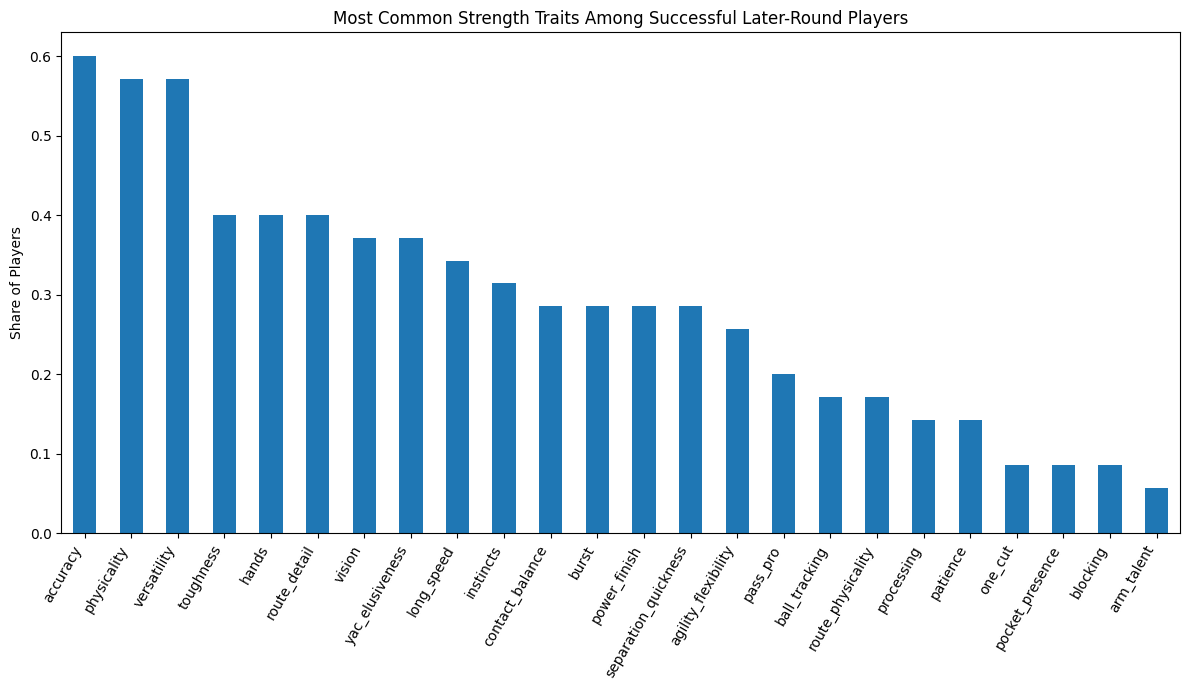

In [86]:
overall_strength = (
    df_traits[strength_flag_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
# Rename labels for better readability
overall_strength.rename(lambda x: x.replace('str_', '').replace('_flag', '')).plot(kind="bar")
plt.title("Most Common Strength Traits Among Successful Later-Round Players")
plt.ylabel("Share of Players")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

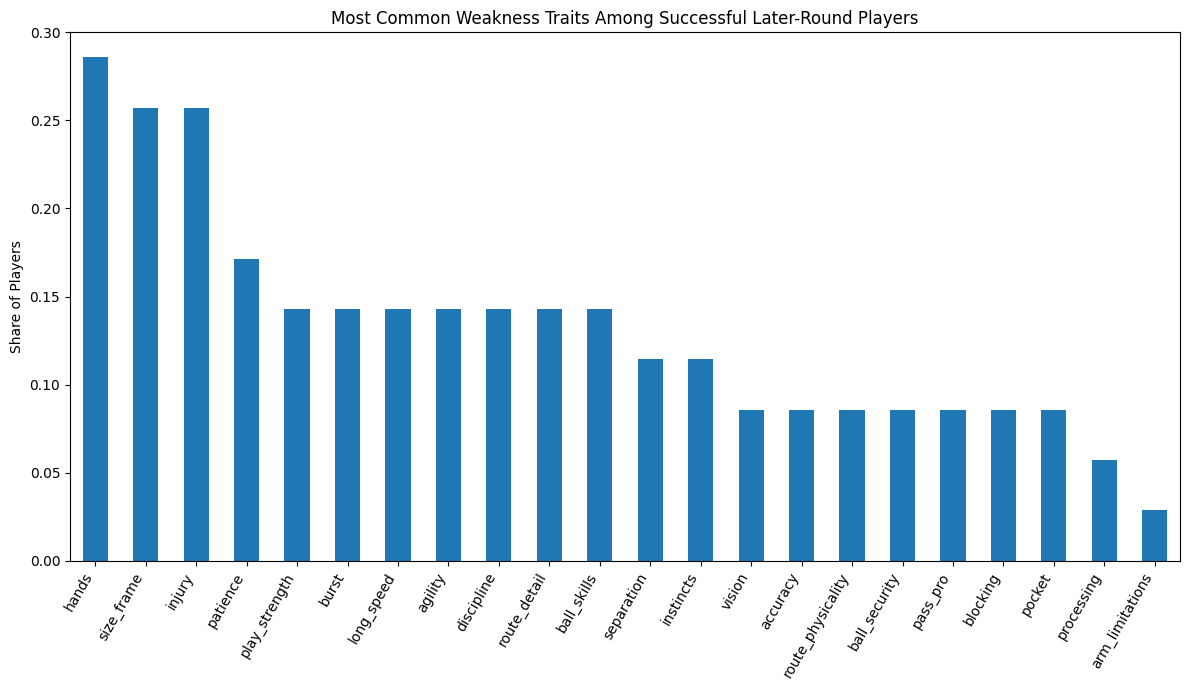

In [87]:
overall_weakness = (
    df_traits[weakness_flag_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
# Rename labels for better readability
overall_weakness.rename(lambda x: x.replace('weak_', '').replace('_issues', '').replace('_flag', '')).plot(kind="bar")
plt.title("Most Common Weakness Traits Among Successful Later-Round Players")
plt.ylabel("Share of Players")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


--- Correlation Matrix of Selected Top Strength and Weakness Traits ---


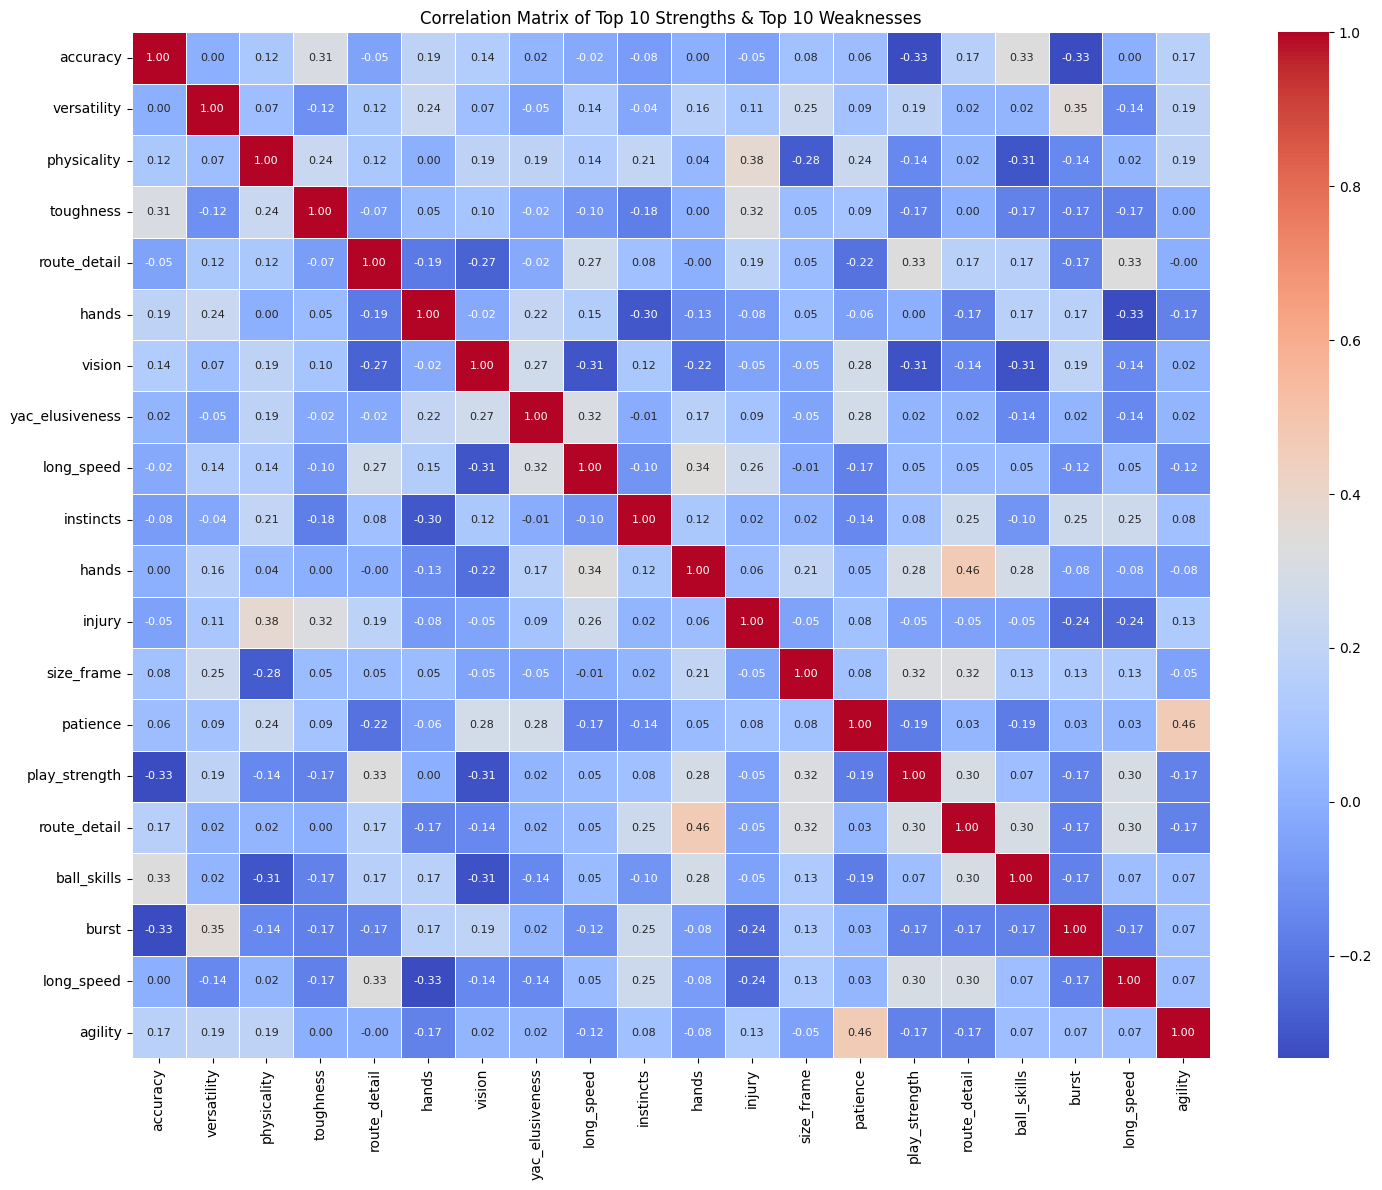

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Correlation Matrix of Selected Top Strength and Weakness Traits for Readability
print("\n--- Correlation Matrix of Selected Top Strength and Weakness Traits ---")

# Recalculate overall strength and weakness frequencies to ensure they are up-to-date
overall_strength = df_traits[strength_flag_cols].mean()
overall_weakness = df_traits[weakness_flag_cols].mean()

# Select top N most common strengths and weaknesses
num_top_traits = 10 # Adjust as needed for readability
top_strength_flags = overall_strength.nlargest(num_top_traits).index.tolist()
top_weakness_flags = overall_weakness.nlargest(num_top_traits).index.tolist()

# Combine these selected flags
selected_trait_flag_cols = top_strength_flags + top_weakness_flags

# Create more readable labels for the heatmap
readable_labels = [col.replace('str_', '').replace('weak_', '').replace('_flag', '').replace('_issues', '') for col in selected_trait_flag_cols]

# Calculate the correlation matrix for only the selected traits
corr_selected = df_traits[selected_trait_flag_cols].corr()

plt.figure(figsize=(15, 12)) # Adjusted figure size for fewer traits
sns.heatmap(corr_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8},
            xticklabels=readable_labels, yticklabels=readable_labels) # Use readable labels
plt.title(f"Correlation Matrix of Top {num_top_traits} Strengths & Top {num_top_traits} Weaknesses")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Most Significant Correlations Between Top Strengths and Weaknesses

In [90]:
# Extract unique correlations (excluding self-correlations and duplicates)
corr_pairs = corr_selected.stack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

# Sort by absolute value to find the most significant ones
significant_correlations = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Format the index for display
def format_trait_name(trait_name):
    return trait_name.replace('str_', '').replace('weak_', '').replace('_flag', '').replace('_issues', '')

# Fix for NotImplementedError: Manually create a new MultiIndex with formatted labels
top_positive = significant_correlations.head(5)
new_index_pos = pd.MultiIndex.from_tuples([(format_trait_name(idx[0]), format_trait_name(idx[1])) for idx in top_positive.index])
formatted_positive_correlations = pd.Series(top_positive.values, index=new_index_pos)

top_negative = significant_correlations.tail(5)
new_index_neg = pd.MultiIndex.from_tuples([(format_trait_name(idx[0]), format_trait_name(idx[1])) for idx in top_negative.index])
formatted_negative_correlations = pd.Series(top_negative.values, index=new_index_neg)

print("Top 5 Positive Correlations:")
display(formatted_positive_correlations)

print("\nTop 5 Negative Correlations:")
display(formatted_negative_correlations)

Top 5 Positive Correlations:


,,0
hands,route_detail,0.464758
patience,agility,0.464238
physicality,injury,0.377426
versatility,burst,0.353553
long_speed,hands,0.342624



Top 5 Negative Correlations:


,,0
hands,play_strength,1.503427e-17
accuracy,long_speed,1.156482e-17
route_detail,hands,-3.583229e-18
toughness,route_detail,3.469447e-18
route_detail,agility,-3.469447e-18


### 1. Most Common Strength and Weakness per Position


--- RB Strengths ---


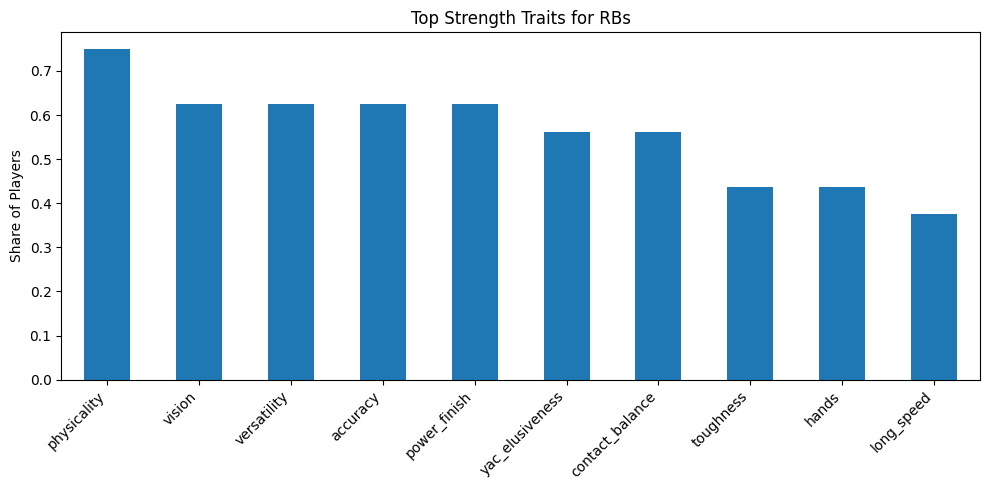


--- RB Weaknesses ---


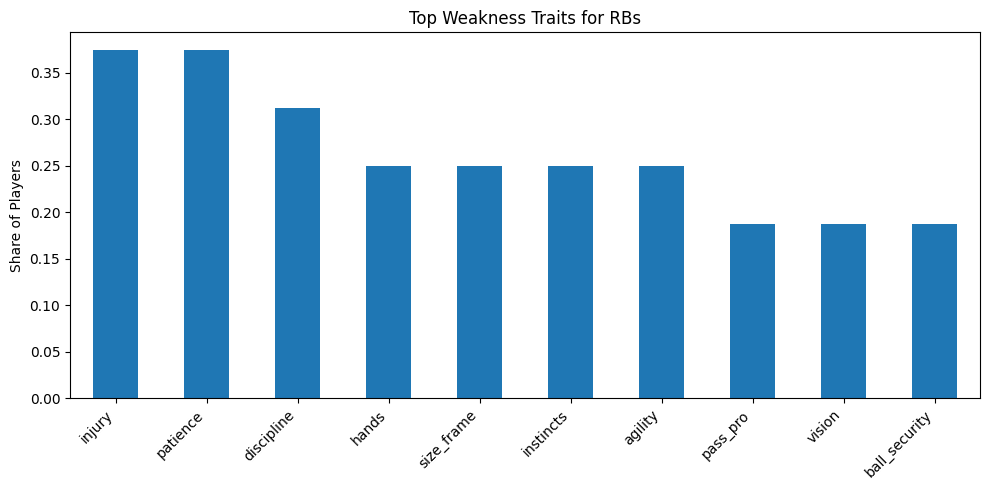


--- WR Strengths ---


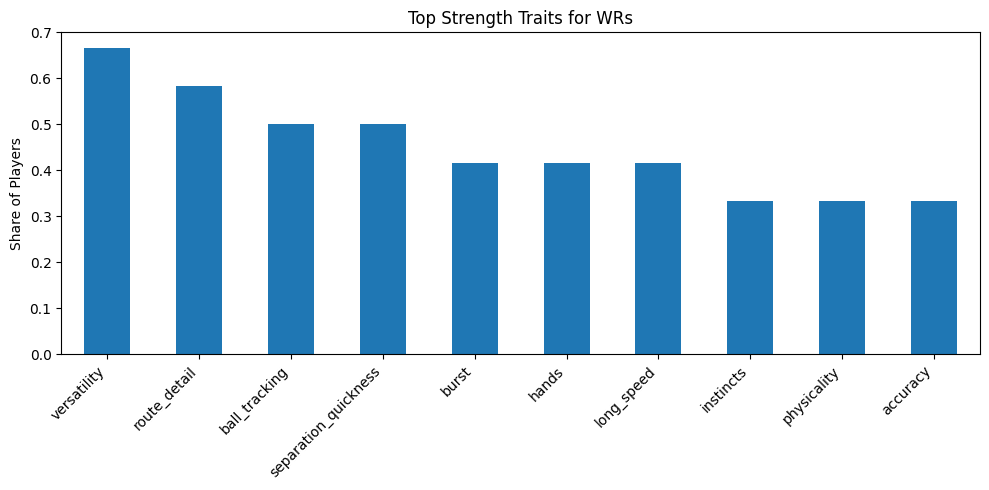


--- WR Weaknesses ---


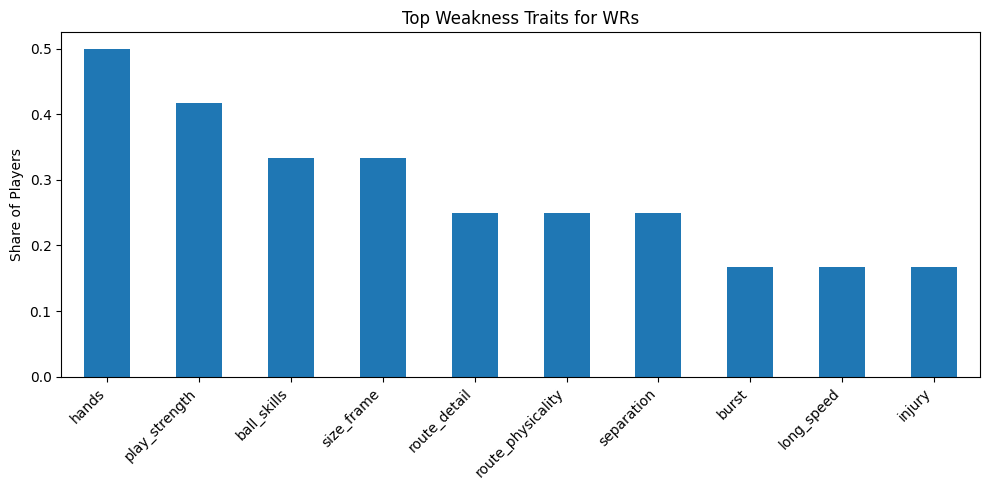


--- QB Strengths ---


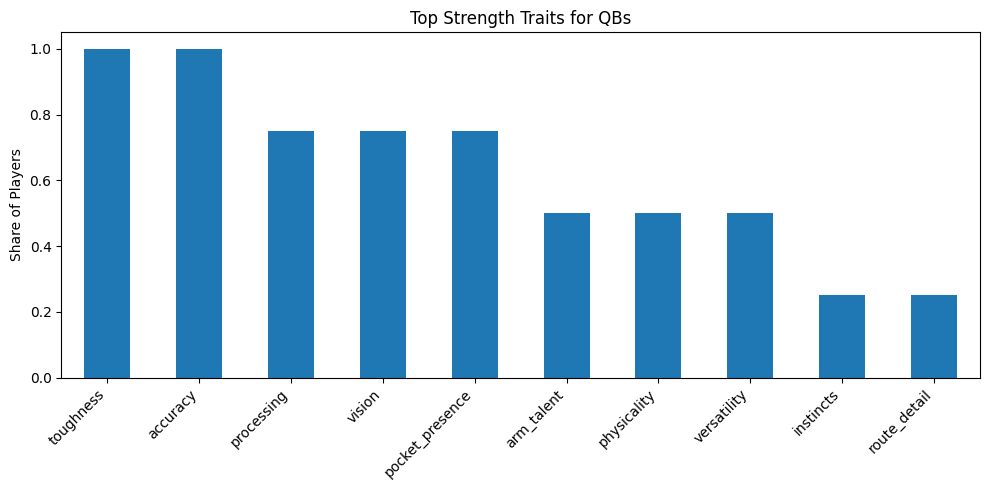


--- QB Weaknesses ---


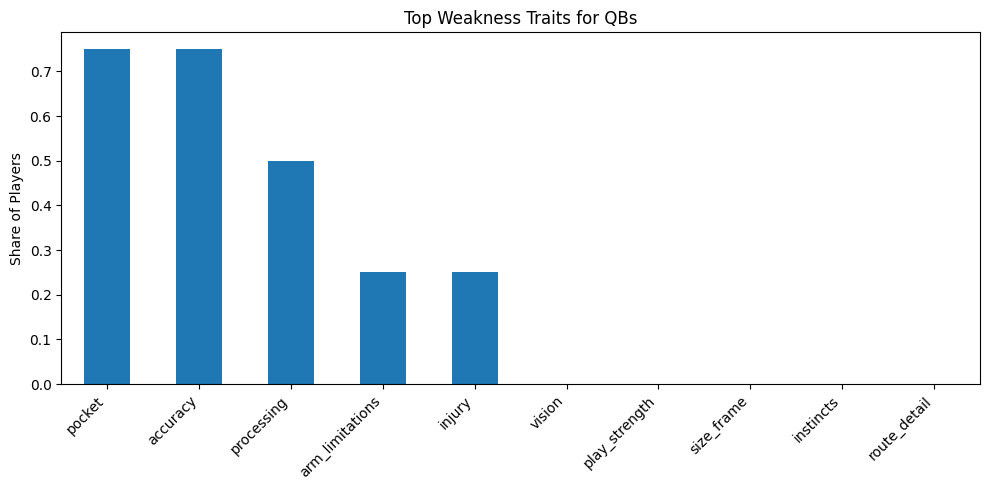


--- TE Strengths ---


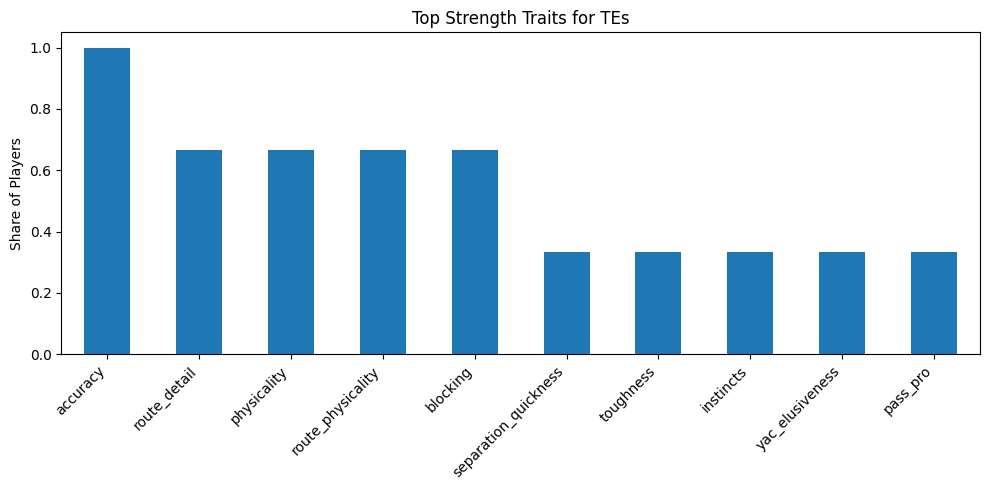


--- TE Weaknesses ---


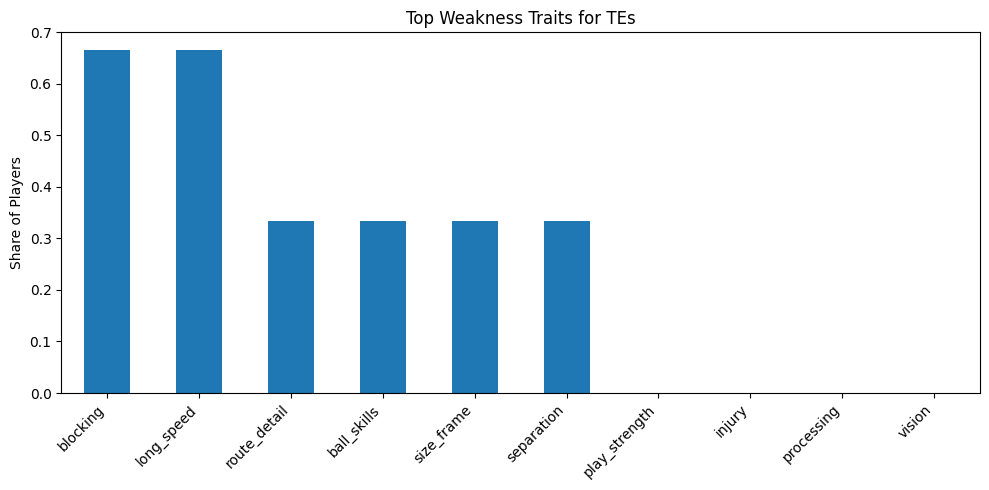

In [92]:
unique_positions = df_traits['position'].unique()

for pos in unique_positions:
    pos_df = df_traits[df_traits['position'] == pos]

    # Calculate strength frequencies for the current position
    pos_strength_flags = pos_df[strength_flag_cols].mean().sort_values(ascending=False)

    # Calculate weakness frequencies for the current position
    pos_weakness_flags = pos_df[weakness_flag_cols].mean().sort_values(ascending=False)

    print(f"\n--- {pos} Strengths ---")
    plt.figure(figsize=(10, 5))
    pos_strength_flags.head(10).rename(lambda x: x.replace('str_', '').replace('_flag', '')).plot(kind='bar')
    plt.title(f'Top Strength Traits for {pos}s')
    plt.ylabel('Share of Players')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\n--- {pos} Weaknesses ---")
    plt.figure(figsize=(10, 5))
    pos_weakness_flags.head(10).rename(lambda x: x.replace('weak_', '').replace('_issues', '').replace('_flag', '')).plot(kind='bar')
    plt.title(f'Top Weakness Traits for {pos}s')
    plt.ylabel('Share of Players')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 2. Distribution of Strengths and Weaknesses per Player

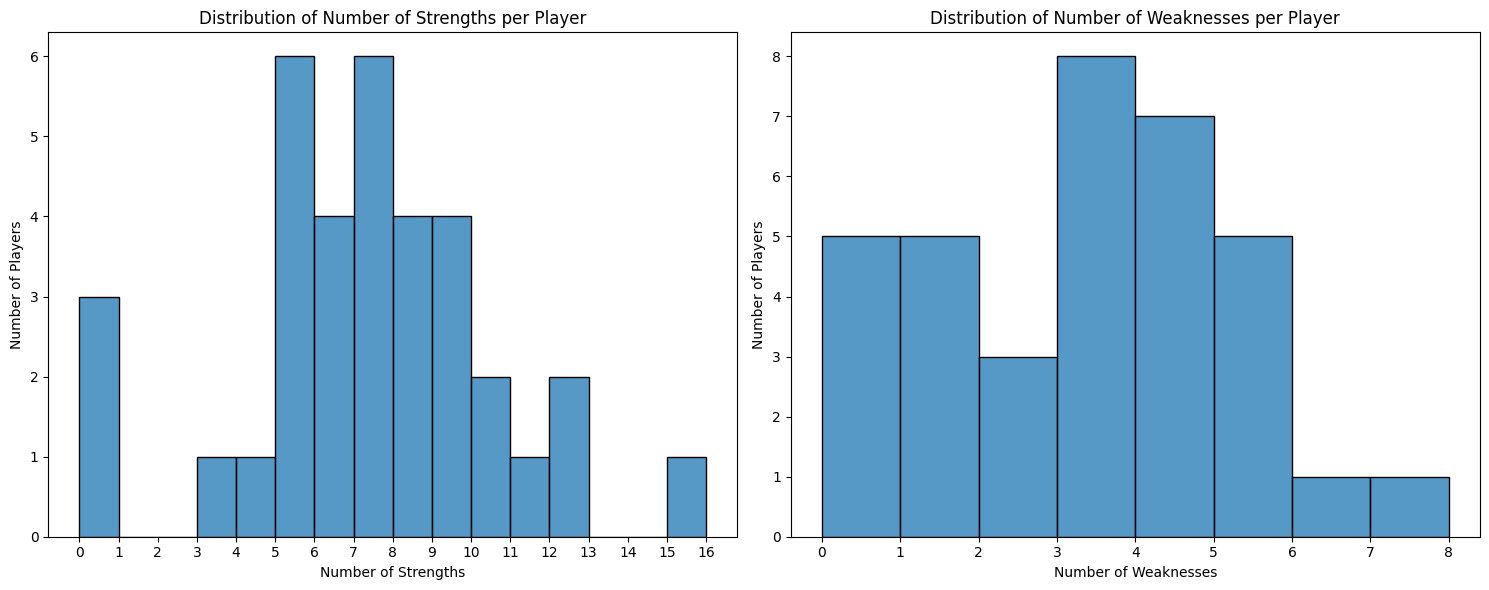

In [93]:
df_traits['num_strengths'] = df_traits[strength_flag_cols].sum(axis=1)
df_traits['num_weaknesses'] = df_traits[weakness_flag_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df_traits['num_strengths'], bins=range(int(df_traits['num_strengths'].max()) + 2), kde=False, ax=axes[0])
axes[0].set_title('Distribution of Number of Strengths per Player')
axes[0].set_xlabel('Number of Strengths')
axes[0].set_ylabel('Number of Players')
axes[0].set_xticks(range(int(df_traits['num_strengths'].max()) + 2))

sns.histplot(df_traits['num_weaknesses'], bins=range(int(df_traits['num_weaknesses'].max()) + 2), kde=False, ax=axes[1])
axes[1].set_title('Distribution of Number of Weaknesses per Player')
axes[1].set_xlabel('Number of Weaknesses')
axes[1].set_ylabel('Number of Players')
axes[1].set_xticks(range(int(df_traits['num_weaknesses'].max()) + 2))

plt.tight_layout()
plt.show()

### 4. "Polarizing" Traits (Mentioned as both Strength and Weakness)


--- Players with traits mentioned as BOTH Strength and Weakness ---


,player_name,position
2,Amon-Ra St. Brown,WR
4,Brock Purdy,QB
8,Dak Prescott,QB
9,Dalton Schultz,TE
10,Darius Slayton,WR
11,Darnell Mooney,WR
15,Diontae Johnson,WR
16,Duke Johnson,RB
20,Jacoby Brissett,QB
27,Nyheim Hines,RB



--- Count of each polarizing trait ---


,0
route_detail,3
accuracy,3
hands,3
long_speed,2
processing,2
vision,1
route_physicality,1
patience,1
blocking,1


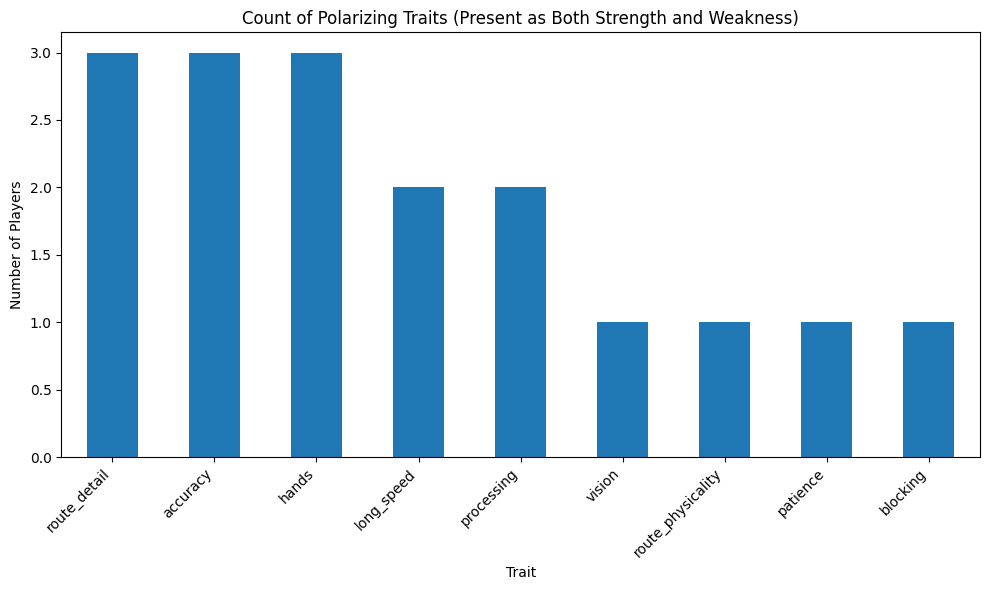

In [95]:
# Map generic trait names to their strength and weakness flag column names
trait_map_flags = {}
for trait in STRENGTH_TRAITS.keys():
    # Assuming a consistent naming convention like 'str_trait_flag' and 'weak_trait_issues_flag'
    # This mapping needs to be robust to the actual column names generated earlier
    # Let's verify the existing flag columns to build this map accurately
    if f'str_{trait}_flag' in df_traits.columns and f'weak_{trait}_issues_flag' in df_traits.columns:
        trait_map_flags[trait] = {
            'strength_flag': f'str_{trait}_flag',
            'weakness_flag': f'weak_{trait}_issues_flag'
        }
    elif f'str_{trait}_flag' in df_traits.columns and f'weak_{trait}_flag' in df_traits.columns:
        # Some weaknesses might not have '_issues' suffix
        trait_map_flags[trait] = {
            'strength_flag': f'str_{trait}_flag',
            'weakness_flag': f'weak_{trait}_flag'
        }

# Identify traits that are present as both strength and weakness for the same player
both_present_traits = pd.DataFrame(index=df_traits.index)

for trait_name, flags in trait_map_flags.items():
    str_flag_col = flags['strength_flag']
    weak_flag_col = flags['weakness_flag']
    both_present_traits[trait_name] = (df_traits[str_flag_col] == 1) & (df_traits[weak_flag_col] == 1)

# Filter to only show players who have at least one polarizing trait
polarizing_players_traits = df_traits[both_present_traits.any(axis=1)][['player_name', 'position']]
polarizing_traits_counts = both_present_traits[both_present_traits.any(axis=1)].sum()

if not polarizing_traits_counts.empty and polarizing_traits_counts.sum() > 0:
    print("\n--- Players with traits mentioned as BOTH Strength and Weakness ---")
    display(polarizing_players_traits)
    print("\n--- Count of each polarizing trait ---")
    display(polarizing_traits_counts[polarizing_traits_counts > 0].sort_values(ascending=False))

    # Optional: Visualize polarizing traits
    plt.figure(figsize=(10, 6))
    polarizing_traits_counts[polarizing_traits_counts > 0].sort_values(ascending=False).plot(kind='bar')
    plt.title('Count of Polarizing Traits (Present as Both Strength and Weakness)')
    plt.xlabel('Trait')
    plt.ylabel('Number of Players')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No players found with traits mentioned as both a strength and a weakness using the current trait definitions and data.")

### 5. Correlation Heatmaps of Traits with Performance Metrics by Position


--- Trait-Performance Correlation Heatmap for RBs ---


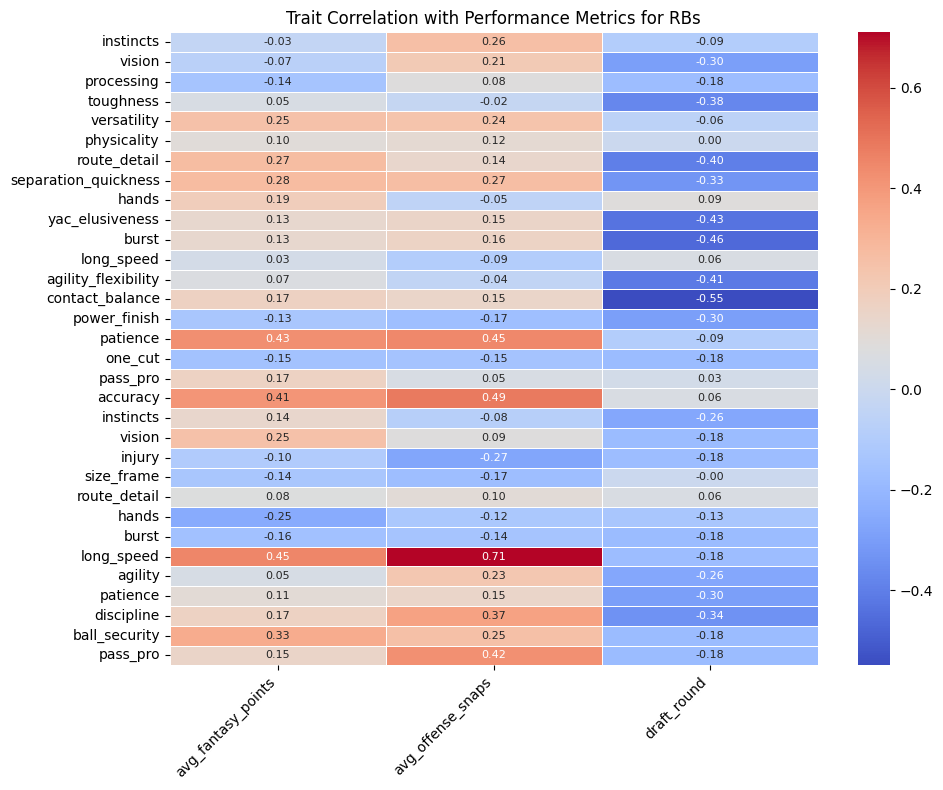


--- Trait-Performance Correlation Heatmap for WRs ---


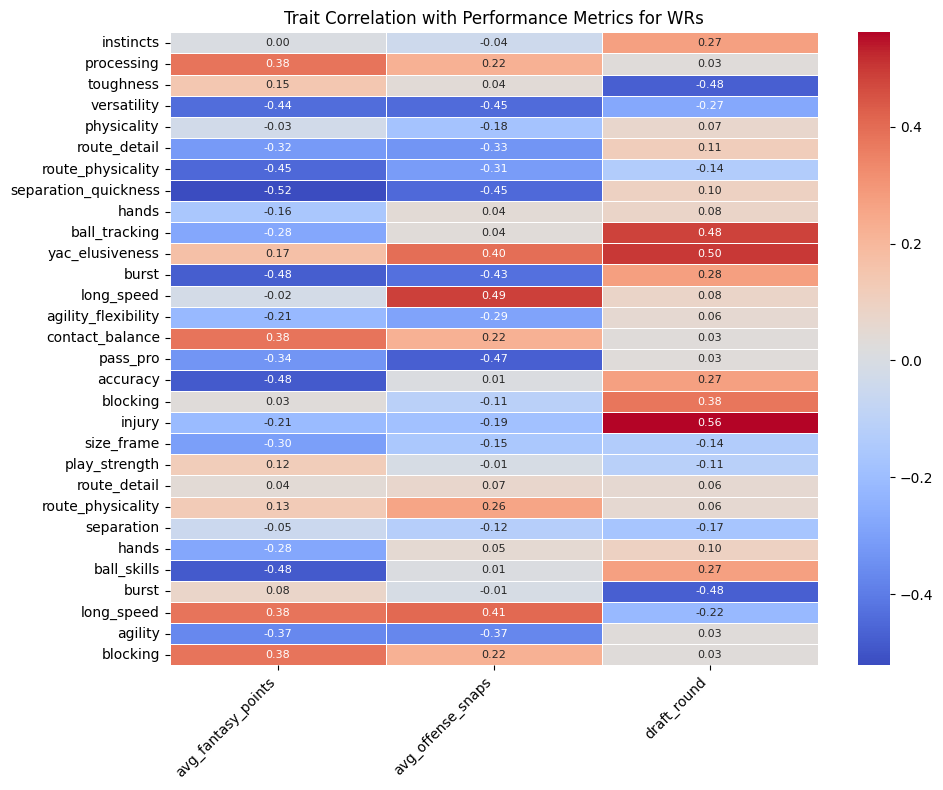


--- Trait-Performance Correlation Heatmap for QBs ---


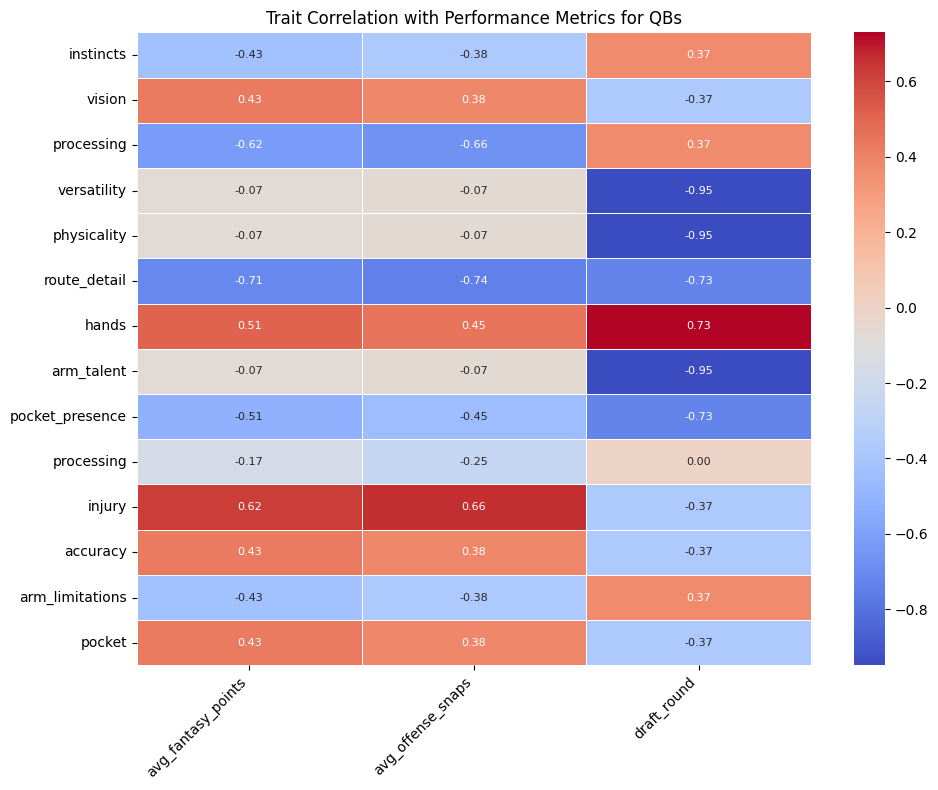


--- Trait-Performance Correlation Heatmap for TEs ---


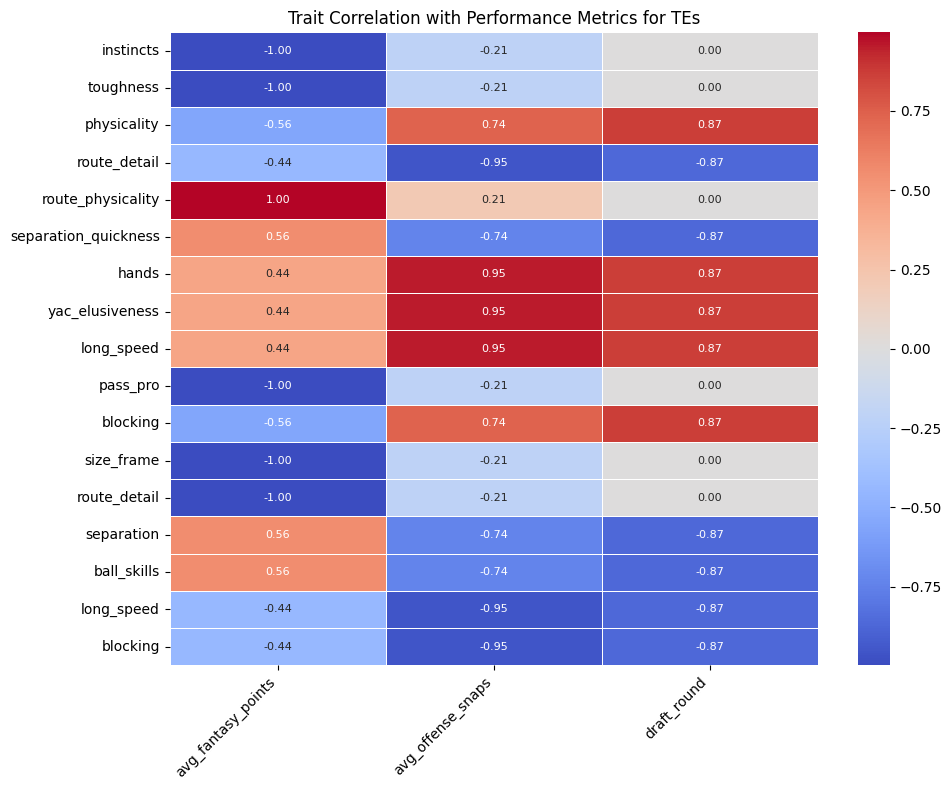

In [97]:
from sklearn.preprocessing import MinMaxScaler

# Aggregate performance metrics for each unique player
player_performance = df_offense.groupby(['player_name', 'position']).agg(
    avg_fantasy_points_ppr=('fantasy_points_ppr', 'mean'),
    avg_offense_snaps=('offense_snaps', 'mean')
).reset_index()

# Get the draft round for each player (assuming it's consistent across seasons for a player)
player_draft_round = df_offense.groupby('player_name')['draft_round'].first().reset_index()
player_performance = pd.merge(player_performance, player_draft_round, on='player_name', how='left')

# Merge df_traits with player performance data
df_final_merged = pd.merge(df_traits, player_performance, on=['player_name', 'position'], how='left')

# Define the performance metrics for correlation
performance_metrics_for_corr = ['avg_fantasy_points_ppr', 'avg_offense_snaps', 'draft_round']

# Scale performance metrics for better visualization in heatmaps if values are widely different
scaler = MinMaxScaler()
for col in performance_metrics_for_corr:
    if col in df_final_merged.columns:
        df_final_merged[f'{col}_scaled'] = scaler.fit_transform(df_final_merged[[col]])

scaled_performance_metrics = [f'{col}_scaled' for col in performance_metrics_for_corr if f'{col}_scaled' in df_final_merged.columns]

# Combine all relevant trait flag columns and scaled performance metrics
correlation_cols = strength_flag_cols + weakness_flag_cols + scaled_performance_metrics

for pos in unique_positions:
    position_df_merged = df_final_merged[df_final_merged['position'] == pos].copy()

    # Ensure there's enough data for correlation calculation
    if len(position_df_merged) < 2:
        print(f"Skipping correlation for {pos}: Not enough data points ({len(position_df_merged)}).")
        continue

    # Filter to only columns that exist in the current position's DataFrame
    position_correlation_cols = [col for col in correlation_cols if col in position_df_merged.columns]
    position_correlation_df = position_df_merged[position_correlation_cols]

    # Drop columns with all NaN or zero variance, as they cause issues in correlation
    position_correlation_df = position_correlation_df.loc[:, position_correlation_df.nunique() > 1] # Drop columns with single unique value (e.g., all 0s or all 1s)
    position_correlation_df = position_correlation_df.dropna(axis=1, how='all') # Drop columns that are all NaN

    if position_correlation_df.empty or len(position_correlation_df.columns) < 2:
        print(f"Skipping correlation for {pos}: Not enough valid columns for correlation after filtering.")
        continue

    position_corr_matrix = position_correlation_df.corr()

    # Filter for relevant correlations (traits with performance metrics)
    # Ensure that only trait columns present in the position_corr_matrix index are selected
    traits_in_matrix = [c for c in position_correlation_cols if c not in scaled_performance_metrics and c in position_corr_matrix.index]

    relevant_correlations = position_corr_matrix.loc[traits_in_matrix, scaled_performance_metrics]

    if not relevant_correlations.empty:
        print(f"\n--- Trait-Performance Correlation Heatmap for {pos}s ---")
        plt.figure(figsize=(10, 8))
        sns.heatmap(relevant_correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8},
                    yticklabels=[col.replace('str_', '').replace('weak_', '').replace('_issues', '').replace('_flag', '') for col in relevant_correlations.index],
                    xticklabels=[col.replace('_scaled', '').replace('_ppr', '') for col in relevant_correlations.columns])
        plt.title(f'Trait Correlation with Performance Metrics for {pos}s')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No relevant trait-performance correlations to display for {pos}s.")

From the analysis of these late-round “hidden gems,” a clear pattern begins to emerge. Many of these players were overlooked not because of a lack of ability, but due to concerns tied to factors they couldn’t fully control—such as injury history, size limitations, or perceived lack of elite speed. These drawbacks often dominated their evaluations, overshadowing the traits that ultimately translated to success at the NFL level.

What stands out is that the players who outperform their draft position tend to excel in areas that are harder to quantify: vision, versatility, effort, and technical skill, such as route running or decision-making. These traits consistently show up across successful late-round picks, suggesting that they may be undervalued during the scouting process.

Additionally, many of these players come from smaller or less prominent programs, which may limit their exposure and further contribute to their draft-day slide. However, their success indicates that high-level performance is not exclusive to powerhouse schools.

Taken together, these insights offer a blueprint for identifying potential hidden gems. Rather than focusing solely on measurable attributes or ideal prototypes, a more balanced evaluation—one that prioritizes functional football skills and on-field impact—can reveal players who are capable of exceeding expectations. For fans and analysts alike, recognizing these patterns provides a deeper understanding of how talent can be overlooked, and how successful teams are often the ones that find value where others do not.

# Thank You

### Data Source

This project uses the "NFL Stats 1999–2022" dataset by Philip Hyde, sourced from Kaggle.  
The dataset contains player-level offensive statistics, draft information, and performance metrics across multiple NFL seasons. :contentReference[oaicite:2]{index=2}


This project also used scouting report available on nfl.com for individual players, that provided strengths and wekanesses for each prospect.

